# Lab3 图像处理

In [ ]:
# import tools
import numpy as np
import cv2
from matplotlib import pyplot as plt

## 1 点运算
这里介绍一些通用的图像处理算子。
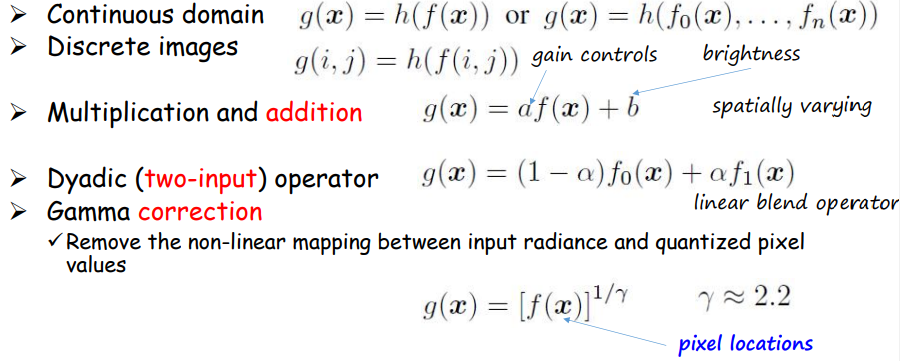
### 1.1 图像合成
将一张图像插入到另一张图像中。
$$
C=(1-\alpha)B+\alpha F
$$
$$
B-背景；F-前景；C-新的合成结果
$$


In [ ]:
img =cv2.imread('lenna.jpg')   # Read image in BGR mode
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img/255.0
back = cv2.imread('back.jpg')
back = cv2.cvtColor(back, cv2.COLOR_BGR2RGB)
back = back/255.0
alpha= cv2.imread('mat.jpg')
alpha = alpha/255.0

composite = cv2.multiply(back,(1-alpha)) + cv2.multiply(img,alpha)

ax1 = plt.subplot(1,4,1)  # Create subplot 1
plt.sca(ax1)              # Choose subplot 1
plt.imshow(img)           # show image on subplot1

ax2 = plt.subplot(1,4,2)  # Create subgplot 2
plt.sca(ax2)              # Choose subplot 2
plt.imshow(back)       # show image on subplot2

ax3 = plt.subplot(1,4,3)  # Create subgplot 3
plt.sca(ax3)              # Choose subplot 3
plt.imshow(alpha)       # show image on subplot3

ax4 = plt.subplot(1,4,4)  # Create subgplot 4
plt.sca(ax4)              # Choose subplot 4
plt.imshow(composite)       # show image on subplot4

plt.show() 

### 1.2 直方图
你可以把直方图看作一张图，它能帮助你整体了解图像的强度分布。横轴是像素值（通常为 0 到 255），纵轴是图像中对应像素值的像素数量。
#### 绘制直方图
OpenCV 和 NumPy 都提供了内置函数来完成这项工作。在使用这些函数之前，需要先了解一些与直方图相关的术语。

**BINS（分箱）**：上面的直方图统计了每个像素值（0 到 255）的像素数量，因此需要 256 个值来表示。

**DIMS（维度）**：表示收集数据的参数个数。这里我们只统计强度值这一项，所以维度是 1。

**RANGE（范围）**：表示要统计的强度值区间。通常为 [0,256]，即所有强度值。

- 使用 OpenCV 计算直方图

现在我们使用 `cv.calcHist()` 函数来计算直方图。先熟悉该函数及其参数：

`cv.calcHist(images, channels, mask, histSize, ranges[, hist[, accumulate]])`
- 使用 NumPy 计算直方图

NumPy 也提供了 `np.histogram()` 函数，因此你也可以不用 `calcHist()`，改用下面这行代码：

`hist,bins = np.histogram(img.ravel(),256,[0,256])`

In [ ]:
img =cv2.imread('lenna.jpg')   # Read image in BGR mode
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# hist = cv.calcHist([img],[0],None,[256],[0,256])
# hist,bins = np.histogram(img.ravel(),256,[0,256])

ax1 = plt.subplot(1,2,1)
ax1.imshow(img); 

ax2 = plt.subplot(1,2,2)
ax2.hist(img2.ravel(),256,[0,256]); 

plt.show()


你也可以使用 Matplotlib 的普通折线图来显示 BGR 通道的直方图。为此需要先计算直方图数据，可尝试下面的代码：

In [ ]:
img =cv2.imread('lenna.jpg')
color = ('b','g','r')
for i,col in enumerate(color):
    histr = cv2.calcHist([img],[i],None,[256],[0,256])
    plt.plot(histr,color = col)
    plt.xlim([0,256])
plt.show()

#### 直方图均衡化
设想一张图像的像素值只集中在某个较窄范围内。例如较亮的图像，其像素值可能集中在较高区域。好的图像通常应覆盖更完整的像素范围。于是我们需要把直方图向两端拉伸（如下图所示），这就是直方图均衡化的核心思想。通常它能提升图像对比度。
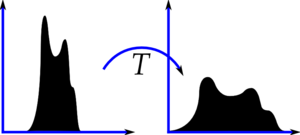

In [ ]:
img =cv2.imread('lenna_hist.jpg')   # Read image in BGR mode
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

hist,bins = np.histogram(img.flatten(),256,[0,256])
 
cdf = hist.cumsum()
cdf_normalized = cdf * float(hist.max()) / cdf.max()

ax1 = plt.subplot(1,2,1)
ax1.imshow(img); 

ax2 = plt.subplot(1,2,2)
ax2.plot(cdf_normalized, color = 'b')
ax2.hist(img.flatten(),256,[0,256], color = 'r')
ax2.legend(('cdf','histogram'), loc = 'upper left')

plt.show()

In [ ]:
#Histograms Equalization using numpy
cdf_m = np.ma.masked_equal(cdf,0)
cdf_m = (cdf_m - cdf_m.min())*255/(cdf_m.max()-cdf_m.min())
cdf = np.ma.filled(cdf_m,0).astype('uint8')

img2 = cdf[img]

ax1 = plt.subplot(1,2,1)
ax1.imshow(img2); 

ax2 = plt.subplot(1,2,2)
ax2.plot(cdf_normalized, color = 'b')
ax2.hist(img2.flatten(),256,[0,256], color = 'r')
ax2.legend(('cdf','histogram'), loc = 'upper left')

plt.show()

In [ ]:
img =cv2.imread('lenna_hist.jpg')   # Read image in BGR mode
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
equ = cv2.equalizeHist(img_gray) # Source 8-bit single channel image.
res = np.hstack((img_gray,equ)) #stacking images side-by-side
plt.imshow(res,cmap='gray');

## 2 邻域算子（线性）
我们使用二维卷积来改变图像的一些特征，常见效果包括：
- 模糊
- 锐化
- 使用保边滤波进行平滑
- 二值图像

### 2.1 均值模糊
图像模糊通过将图像与低通滤波核进行卷积实现，常用于去噪。它本质上会削弱图像中的高频成分（如噪声和边缘）。当卷积核大小为 ($3,3$) 时，核可以写作：
$$
k=\frac{1}{9}
\begin{pmatrix}
1 & 1 & 1\\
1& 1& 1\\
1& 1& 1\\
\end{pmatrix}
$$


In [ ]:
img = cv2.imread('lenna.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

kernel = np.ones((5,5),np.float32)/25
dst = cv2.filter2D(img,-1,kernel)

blur = cv2.blur(img,(5,5))

plt.subplot(131),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(dst),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(blur),plt.title('Blur')
plt.xticks([]), plt.yticks([])
plt.show()

### 2.2 高斯模糊
高斯模糊使用高斯核而不是方框滤波核，可通过 `cv2.GaussianBlur()` 实现。它对去除高斯噪声非常有效。
该卷积核满足如下高斯函数形式：
$$
G(x,y)=\frac{1}{2\pi\sigma^2}e^{-\frac{x^2+y^2}{2\sigma^2}}
$$
例如，当高斯核大小为 ($3,3$) 时，可写为：
$$
k=\frac{1}{16}
\begin{pmatrix}
1&2&1\\
2&4&2\\
1&2&1\\
\end{pmatrix}
$$


In [ ]:
img = cv2.imread('lenna.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(img.dtype) # show the type of img

# create gaussian-nosie
row, col, ch = img.shape #get height,width,channal
mean=0
sigma=20
gauss = np.random.normal(mean, sigma, (row, col, ch))
img_noise = img + gauss 
img_noise = np.clip(img_noise, 0, 255).astype(np.uint8)#boundary the data of img

blur = cv2.GaussianBlur(img,(5,5),0)
blur_noise = cv2.GaussianBlur(img_noise,(5,5),0)

plt.figure(1, figsize=(10,10))
plt.subplot(221),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(222),plt.imshow(blur),plt.title('Blur')
plt.xticks([]), plt.yticks([])
plt.subplot(223),plt.imshow(img_noise),plt.title('Noise')
plt.xticks([]), plt.yticks([])
plt.subplot(224),plt.imshow(blur_noise),plt.title('Noise-Blur')
plt.xticks([]), plt.yticks([])
plt.show()

## 3 邻域算子（非线性）
- 中值滤波
- 双边滤波

### 3.1 中值滤波
这里使用 `cv2.medianBlur()`，它会计算核窗口内所有像素的中位数，并用该中位数替换中心像素。该方法对椒盐噪声非常有效。例如，图像中一个大小为 $(3,3)$ 的窗口：
$$
\begin{pmatrix}
20&10&25\\
15&30&5\\
50&35&40\\
\end{pmatrix}
$$
其中中位数为 25，因此将中心值 30 替换为 25。

In [ ]:
img = cv2.imread('lenna.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# create salt-pepper noise img
prob = 0.02 #the ratio of noise and pixels will be 2%
img_noise = np.copy(img)

salt = np.random.rand(*img.shape)<prob
img_noise[salt]= 255
pepper = np.random.rand(*img.shape)<prob
img_noise[pepper] = 0

median = cv2.medianBlur(img,5)
median_noise = cv2.medianBlur(img_noise,5)

#
plt.figure(1, figsize=(10,10))
plt.subplot(221),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(222),plt.imshow(median),plt.title('median')
plt.xticks([]), plt.yticks([])
plt.subplot(223),plt.imshow(img_noise),plt.title('Noise')
plt.xticks([]), plt.yticks([])
plt.subplot(224),plt.imshow(median_noise),plt.title('Noise-medianfilter')
plt.xticks([]), plt.yticks([])
plt.show()

### 3.2 双边滤波
`cv2.bilateralFilter()` 在去噪的同时能较好地保留边缘，但计算速度通常比其他滤波器慢。
在该滤波器中，输出像素可表示为：
$$
I_{filtered}(x,y)=\frac{1}{W_{total}}\Sigma I(i,j) \cdot \omega_s(i,j) \cdot \omega_r(i,j)
$$

- $I(i,j)$ 表示邻域 $\Omega$ 中的像素值

- $\omega_s(i,j)$ 为空间权重，表示像素间的距离关系
$$
\omega_s(i,j)=exp(-\frac{(i-x)^2+(j-y)^2}{2\sigma^2_s})
$$

- $\omega_r(i,j)$ 为像素值权重，表示像素间的相似性
$$
\omega_r(i,j)=exp(-\frac{(I(i,j)-I(x,y))^2}{2\sigma^2_r})
$$

- $W_{total}$ 为归一化因子，用于保证：
$$
W_{total}=\Sigma \omega_s(i,j) \cdot \omega_r(i,j)=1
$$

In [ ]:
img = cv2.imread('lenna.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# create salt-pepper noise img
prob = 0.02 #the ratio of noise and pixels will be 2%
img_noise = np.copy(img)

salt = np.random.rand(*img.shape)<prob
img_noise[salt]= 255
pepper = np.random.rand(*img.shape)<prob
img_noise[pepper] = 0

# bilateralFilter(src, d, sigmaColor, sigmaSpace[, dst[, borderType]]) → dst
bf = cv2.bilateralFilter(img,90,90,5)
bf_noise = cv2.bilateralFilter(img_noise,90,90,5)

#
plt.figure(1, figsize=(10,10))
plt.subplot(221),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(222),plt.imshow(bf),plt.title('bilateralFilter')
plt.xticks([]), plt.yticks([])
plt.subplot(223),plt.imshow(img_noise),plt.title('Noise')
plt.xticks([]), plt.yticks([])
plt.subplot(224),plt.imshow(bf_noise),plt.title('Noise-bilateralFilter')
plt.xticks([]), plt.yticks([])
plt.show()

## 4 形态学
形态学变换是基于图像形状的一类简单操作，通常应用于二值图像。它需要两个输入：原始图像与结构元素（`structuring element`，也称 `kernel`），后者决定操作方式。最基本的两个形态学算子是腐蚀与膨胀，其及其变体如下：
- 膨胀
- 腐蚀
- 多数滤波
- 开运算
- 闭运算
- 连通域

### 4.1 膨胀与腐蚀
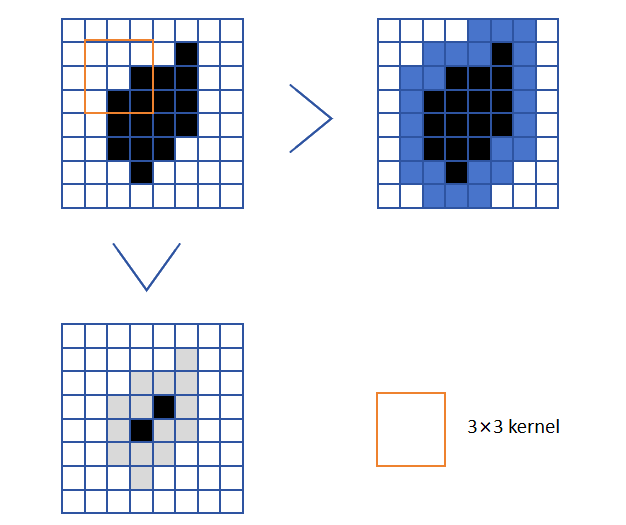

In [ ]:
img = cv2.imread('j.png',0)
kernel = np.ones((5,5),np.uint8)
erosion = cv2.erode(img,kernel,iterations = 1)
dilation = cv2.dilate(img,kernel,iterations = 1)

plt.subplot(131),plt.imshow(img,cmap='gray'),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(erosion,cmap='gray'),plt.title('erode')
plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(dilation,cmap='gray'),plt.title('dilate')
plt.xticks([]), plt.yticks([])
plt.show()

### 4.2 多数滤波
多数投票常用于二值图像处理或多分类问题。其核心思想是在滑动窗口中统计像素值的众数（出现次数最多的值），并用该众数替换中心像素值。例如，窗口内区域为：
$$
\begin{pmatrix}
1&1&0\\
0&0&1\\
1&1&0\\
\end{pmatrix}
$$
在这个窗口中，`1` 的数量多于 `0`，因此将中心值改为 1。 



In [ ]:
img = cv2.imread('j.png',0)
kernel = np.ones((5,5),np.uint8)
erosion = cv2.erode(img,kernel,iterations = 1)
dilation = cv2.dilate(img,kernel,iterations = 1)

height, width = img.shape[:2]
filtered_img = np.copy(img)

kernel =5
radius = kernel// 2

for y in range(radius, height - radius):
    for x in range(radius, width - radius):
        # Extract pixel values within the sliding window
        window = img[y - radius:y + radius + 1, x - radius:x + radius + 1]
            
        # Count the mode
        values, counts = np.unique(window, return_counts=True)
        majority_value = values[np.argmax(counts)]
            
        # Update the center pixel's value
        filtered_img[y, x] = majority_value

plt.subplot(131),plt.imshow(img,cmap='gray'),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(filtered_img,cmap='gray'),plt.title('Majority')
plt.xticks([]), plt.yticks([])

plt.show()

### 4.3 开运算
开运算即先腐蚀后膨胀。正如上文所述，它常用于去除噪声。这里我们使用 `cv2.morphologyEx()`

In [ ]:
img = cv2.imread('j.png',0)
kernel = np.ones((5,5),np.uint8)

prob = 0.02 #the ratio of noise and pixels will be 2%
img_noise = np.copy(img)

salt = np.random.rand(*img.shape)<prob
img_noise[salt]= 255

opening = cv2.morphologyEx(img_noise, cv2.MORPH_OPEN, kernel)

plt.subplot(131),plt.imshow(img,cmap='gray'),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(img_noise,cmap='gray'),plt.title('+noise')
plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(opening,cmap='gray'),plt.title('Opening')
plt.xticks([]), plt.yticks([])
plt.show()

### 4.4 闭运算
闭运算与开运算相反，即先膨胀后腐蚀。它适合填补前景目标内部的小孔洞，或去除目标上的小黑点。

In [ ]:
img = cv2.imread('j.png',0)
kernel = np.ones((5,5),np.uint8)

prob = 0.02 #the ratio of noise and pixels will be 2%
img_hole = np.copy(img)

pepper = np.random.rand(*img.shape)<prob
img_hole[pepper]= 0

closing = cv2.morphologyEx(img_noise, cv2.MORPH_CLOSE, kernel)

plt.subplot(131),plt.imshow(img,cmap='gray'),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(img_hole,cmap='gray'),plt.title('+hole')
plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(closing,cmap='gray'),plt.title('Closing')
plt.xticks([]), plt.yticks([])
plt.show()

### 4.5 连通域
在布尔图像上按 4 邻域或 8 邻域计算连通域标记图。函数返回标签总数 N（标签范围为 0 到 N-1），其中 0 表示背景标签。

In [ ]:
img = cv2.imread('j.png',0)
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(img, connectivity=8)

img_out = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)

for i in range(1, num_labels):
    img_out[labels == i] = np.random.randint(0, 255, size=3)

plt.subplot(121),plt.imshow(img,cmap='gray'),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(img_out),plt.title('Connected Component')
plt.xticks([]), plt.yticks([])
plt.show()